In [1]:
# ============================================
# 1. БАЗОВЫЕ БИБЛИОТЕКИ
# ============================================
import numpy as np
import pandas as pd
import re
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 2. ВИЗУАЛИЗАЦИЯ
# ============================================
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
%matplotlib inline

# ============================================
# 3. ПРЕДОБРАБОТКА
# ============================================
from sklearn.preprocessing import LabelEncoder

# ============================================
# 4. МОДЕЛЬ
# ============================================
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier

# ============================================
# 5. ОЦЕНКА
# ============================================
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.model_selection import learning_curve

# ============================================
# 6. BASELINE СРАВНЕНИЕ
# ============================================
from sklearn.linear_model import LogisticRegression

# ============================================
# 7. НАСТРОЙКИ ОТОБРАЖЕНИЯ
# ============================================
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

In [2]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')


In [3]:
print("=== ПРОПУСКИ В TRAIN ===")
missing_train = pd.DataFrame({
    'Пропусков': train_df.isnull().sum(),
    'Процент %': (train_df.isnull().sum() / len(train_df) * 100).round(2)
}).sort_values('Процент %', ascending=False)

print(missing_train[missing_train['Пропусков'] > 0])

print("\n=== ПРОПУСКИ В TEST ===")
missing_test = pd.DataFrame({
    'Пропусков': test_df.isnull().sum(),
    'Процент %': (test_df.isnull().sum() / len(test_df) * 100).round(2)
}).sort_values('Процент %', ascending=False)

print(missing_test[missing_test['Пропусков'] > 0])

=== ПРОПУСКИ В TRAIN ===
          Пропусков  Процент %
Cabin           687      77.10
Age             177      19.87
Embarked          2       0.22

=== ПРОПУСКИ В TEST ===
       Пропусков  Процент %
Cabin        327      78.23
Age           86      20.57
Fare           1       0.24


In [4]:
test_passenger_ids = test_df['PassengerId'].copy()

# Сохраняем целевую переменную:
y_train = train_df['Survived'].copy()

# Объединяем для единой предобработки:
full_df = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

print(f"Train: {train_df.shape}")
print(f"Test: {test_df.shape}")
print(f"Full: {full_df.shape}")

Train: (891, 12)
Test: (418, 11)
Full: (1309, 12)


In [5]:
full_df['Title'] = full_df['Name'].str.extract(r'([A-Za-z]+)\.')

# Редкие титулы объединяем:
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don',
               'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
full_df['Title'] = full_df['Title'].replace(rare_titles, 'Rare')
full_df['Title'] = full_df['Title'].replace({'Mlle': 'Miss',
                                              'Ms': 'Miss',
                                              'Mme': 'Mrs'})

# Маппинг вместо LabelEncoder:
title_map = {
    'Mr': 1,
    'Miss': 2,
    'Mrs': 3,
    'Master': 4,
    'Rare': 5
}
full_df['Title'] = full_df['Title'].map(title_map)

print(full_df['Title'].value_counts())
print(f"Пропуски в Title: {full_df['Title'].isnull().sum()}")

Title
1    757
2    264
3    198
4     61
5     29
Name: count, dtype: int64
Пропуски в Title: 0


In [6]:
# 2. Размер семьи:
full_df['FamilySize'] = full_df['SibSp'] + full_df['Parch'] + 1
# 3. Один или нет:
full_df['IsAlone'] = (full_df['FamilySize'] == 1).astype(int)
# 4. Наличие каюты:
full_df['Has_Cabin'] = full_df['Cabin'].notna().astype(int)
# 5. Палуба из номера каюты:
full_df['Deck'] = full_df['Cabin'].str.extract(r'([A-Za-z])')
full_df['Deck'] = full_df['Deck'].fillna('Unknown')

print("Базовые признаки добавлены!")

Базовые признаки добавлены!


In [7]:
# train часть = первые 891 строк
train_part = full_df[:891]

# Embarked — мода только по train:
embarked_mode = train_part['Embarked'].mode()[0]
full_df['Embarked'] = full_df['Embarked'].fillna(embarked_mode)
print(f"Embarked заполнен: {embarked_mode}")

# Fare — медиана по Pclass только по train:
fare_median_by_class = train_part.groupby('Pclass')['Fare'].median()
print(f"\nМедиана Fare по классам:\n{fare_median_by_class}")

def fill_fare(row):
    if pd.isna(row['Fare']):
        return fare_median_by_class[row['Pclass']]
    return row['Fare']

full_df['Fare'] = full_df.apply(fill_fare, axis=1)

# Age — медиана по Title + Pclass только по train:
age_median = train_part.groupby(['Title', 'Pclass'])['Age'].median()
print(f"\nМедиана Age по Title+Pclass:\n{age_median}")

def fill_age(row):
    if pd.isna(row['Age']):
        try:
            return age_median[row['Title'], row['Pclass']]
        except KeyError:
            return train_part['Age'].median()
    return row['Age']

full_df['Age'] = full_df.apply(fill_age, axis=1)

# Проверка:
print("\nПропуски после заполнения:")
print(full_df[['Age', 'Embarked', 'Fare']].isnull().sum())

Embarked заполнен: S

Медиана Fare по классам:
Pclass
1    60.2875
2    14.2500
3     8.0500
Name: Fare, dtype: float64

Медиана Age по Title+Pclass:
Title  Pclass
1      1         40.0
       2         31.0
       3         26.0
2      1         30.0
       2         24.0
       3         18.0
3      1         40.0
       2         32.0
       3         31.0
4      1          4.0
       2          1.0
       3          4.0
5      1         48.5
       2         46.5
Name: Age, dtype: float64

Пропуски после заполнения:
Age         0
Embarked    0
Fare        0
dtype: int64


In [8]:
# ============================================
# 5.1 ДОПОЛНИТЕЛЬНЫЕ ПРИЗНАКИ
# (после заполнения пропусков!)
# ============================================
# Age * Pclass взаимодействие:
full_df['Age_Pclass'] = full_df['Age'] * full_df['Pclass']

# Fare на человека:
full_df['Fare_per_person'] = full_df['Fare'] / full_df['FamilySize']

# Категория возраста:
full_df['Age_Group'] = pd.cut(
    full_df['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=[0, 1, 2, 3, 4]
).astype(int)

# Категория размера семьи:
def family_category(size):
    if size == 1:
        return 0  # одиночка
    elif size <= 4:
        return 1  # маленькая семья
    else:
        return 2  # большая семья

full_df['Family_Category'] = full_df['FamilySize'].apply(family_category)

print("Новые признаки добавлены!")
print(f"Всего колонок: {full_df.shape[1]}")
print(f"\nВсе признаки:")
print(full_df.columns.tolist())

Новые признаки добавлены!
Всего колонок: 21

Все признаки:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'Has_Cabin', 'Deck', 'Age_Pclass', 'Fare_per_person', 'Age_Group', 'Family_Category']


In [9]:

le = LabelEncoder()

# Кодируем категориальные признаки:
categorical_cols = ['Sex', 'Embarked', 'Deck']

for col in categorical_cols:
    full_df[col] = le.fit_transform(full_df[col].astype(str))
    print(f"{col}: {full_df[col].unique()}")

print("\nТипы данных после кодирования:")
print(full_df[categorical_cols].dtypes)

Sex: [1 0]
Embarked: [2 0 1]
Deck: [8 2 4 6 3 0 1 5 7]

Типы данных после кодирования:
Sex         int64
Embarked    int64
Deck        int64
dtype: object


In [10]:
# Проверка что нет NaN в новых признаках:
print(full_df[['Age_Pclass', 'Fare_per_person', 'Age_Group']].isnull().sum())

Age_Pclass         0
Fare_per_person    0
Age_Group          0
dtype: int64


In [11]:

# Колонки которые удаляем:
drop_cols = ['PassengerId', 'Name', 'Ticket',
             'Cabin', 'SibSp', 'Parch',
             'IsAlone',      
             'Age_Group'] 

full_df = full_df.drop(columns=drop_cols)

print("Оставшиеся признаки:")
print(full_df.columns.tolist())
print(f"\nРазмер: {full_df.shape}")

Оставшиеся признаки:
['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'Title', 'FamilySize', 'Has_Cabin', 'Deck', 'Age_Pclass', 'Fare_per_person', 'Family_Category']

Размер: (1309, 13)


In [12]:
# Разделяем обратно на train и test:
X_train = full_df[:891].drop(columns=['Survived'])
X_test = full_df[891:].drop(columns=['Survived'])

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")

# Финальная проверка пропусков:
print("\nПропуски в X_train:")
print(X_train.isnull().sum())
print("\nПропуски в X_test:")
print(X_test.isnull().sum())

X_train: (891, 12)
X_test: (418, 12)
y_train: (891,)

Пропуски в X_train:
Pclass             0
Sex                0
Age                0
Fare               0
Embarked           0
Title              0
FamilySize         0
Has_Cabin          0
Deck               0
Age_Pclass         0
Fare_per_person    0
Family_Category    0
dtype: int64

Пропуски в X_test:
Pclass             0
Sex                0
Age                0
Fare               0
Embarked           0
Title              0
FamilySize         0
Has_Cabin          0
Deck               0
Age_Pclass         0
Fare_per_person    0
Family_Category    0
dtype: int64


In [13]:
# ============================================
# 8. BASELINE — RANDOM FOREST
# ============================================

rf_baseline = RandomForestClassifier(random_state=42)

baseline_scores = cross_val_score(
    rf_baseline, X_train, y_train,
    cv=5, scoring='accuracy'
)

print("=== BASELINE (Random Forest) ===")
print(f"Scores: {baseline_scores.round(3)}")
print(f"Среднее: {baseline_scores.mean():.3f}")
print(f"Std: {baseline_scores.std():.3f}")

=== BASELINE (Random Forest) ===
Scores: [0.81  0.809 0.837 0.77  0.848]
Среднее: 0.815
Std: 0.027


In [14]:
# ============================================
# 9. GRIDSEARCH — RANDOM FOREST
# ============================================

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'min_samples_leaf': [3, 4, 5],
    'min_samples_split': [4, 6, 8],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Лучшие параметры RF: {grid_search.best_params_}")
print(f"Лучший CV score RF:  {grid_search.best_score_:.3f}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Лучшие параметры RF: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 300}
Лучший CV score RF:  0.835


In [15]:

# ============================================
# 9. GRIDSEARCHCV — РАСШИРЕННЫЙ
# ============================================

param_grid_gb = {
    'n_estimators': [100, 200],
    'max_depth': [2, 3],          # ← меньше!
    'learning_rate': [0.05, 0.1], # ← меньше!
    'min_samples_leaf': [4, 5, 6], # ← больше!
    'subsample': [0.8, 0.9]        # ← новый параметр!
}

grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_gb.fit(X_train, y_train)

print(f"Лучшие параметры: {grid_gb.best_params_}")
print(f"Лучший CV score: {grid_gb.best_score_:.3f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 6, 'n_estimators': 100, 'subsample': 0.9}
Лучший CV score: 0.842


=== ВАЖНОСТЬ ПРИЗНАКОВ ===
            Feature  Importance
5             Title    0.267816
1               Sex    0.232400
9        Age_Pclass    0.097570
10  Fare_per_person    0.071261
0            Pclass    0.068493
3              Fare    0.059648
8              Deck    0.045912
2               Age    0.045274
6        FamilySize    0.043157
11  Family_Category    0.035674
7         Has_Cabin    0.022820
4          Embarked    0.009975


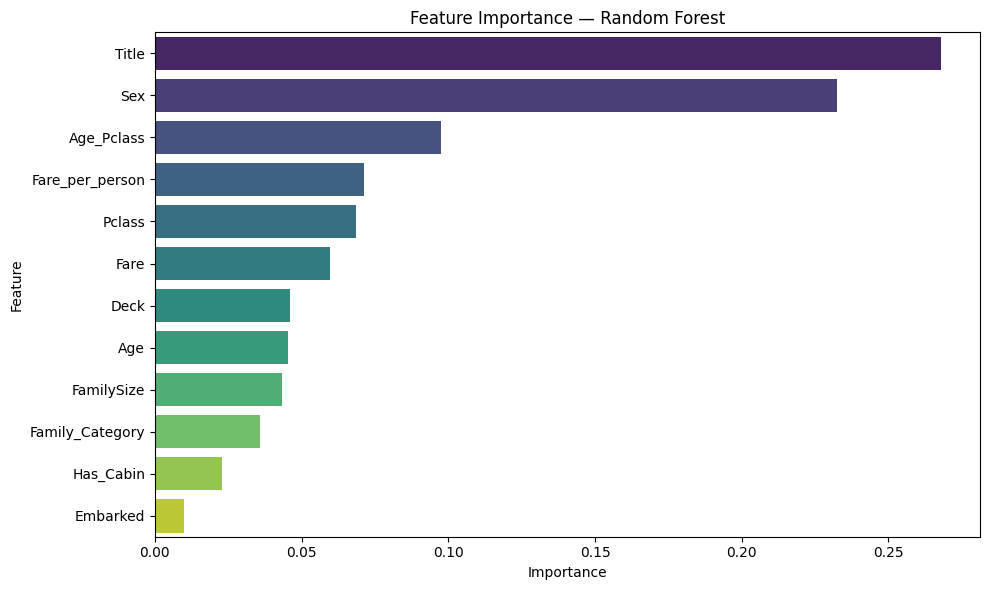

In [16]:

# Берём лучшие параметры из GridSearch:
best_model = grid_search.best_estimator_

# Обучаем на ВСЁМ train:
best_model.fit(X_train, y_train)

# Важность признаков:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("=== ВАЖНОСТЬ ПРИЗНАКОВ ===")
print(feature_importance)

# Визуализация:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature',
    palette='viridis'
)
plt.title('Feature Importance — Random Forest')
plt.tight_layout()
plt.show()

In [17]:
# ============================================
# 10. SEED AVERAGE
# ============================================

# Seed Average для GradientBoosting:
predictions_gb = []
for seed in range(50):
    model_gb = GradientBoostingClassifier(
        **grid_gb.best_params_,
        random_state=seed
    )
    model_gb.fit(X_train, y_train)
    predictions_gb.append(
        model_gb.predict_proba(X_test)[:,1]
    )

final_gb = np.mean(predictions_gb, axis=0)
predictions = (final_gb >= 0.5).astype(int)

submission = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Survived': predictions.astype(int)
})
submission.to_csv('submission.csv', index=False)
print(f"✅ submission.csv готов!")
print(f"Выживших: {predictions.sum()}")

✅ submission.csv готов!
Выживших: 156


In [18]:
# ============================================
# ФИНАЛЬНАЯ ОЦЕНКА — GRADIENT BOOSTING
# ============================================

best_gb = GradientBoostingClassifier(
    **grid_gb.best_params_,
    random_state=42
)

final_gb_scores = cross_val_score(
    best_gb, X_train, y_train,
    cv=5, scoring='accuracy'
)

print("=== ФИНАЛЬНАЯ ОЦЕНКА GB ===")
print(f"Scores: {final_gb_scores.round(3)}")
print(f"CV Accuracy: {final_gb_scores.mean():.3f}")
print(f"Std: {final_gb_scores.std():.3f}")

best_gb.fit(X_train, y_train)
train_acc = best_gb.score(X_train, y_train)
print(f"Train Accuracy: {train_acc:.3f}")
print(f"Разрыв: {train_acc - final_gb_scores.mean():.3f}")

=== ФИНАЛЬНАЯ ОЦЕНКА GB ===
Scores: [0.849 0.826 0.86  0.82  0.854]
CV Accuracy: 0.842
Std: 0.016
Train Accuracy: 0.901
Разрыв: 0.059


In [19]:
# ============================================
# 11. SUBMISSION
# ============================================

submission = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Survived': predictions.astype(int)
})

# Проверка:
print(f"Строк: {len(submission)}")
print(f"Пропуски: {submission.isnull().sum().sum()}")
print(f"Уникальные значения: {submission['Survived'].unique()}")
print(f"\nРаспределение:")
print(submission['Survived'].value_counts())

# Сохраняем:
submission.to_csv('submission.csv', index=False)
print("\n✅ submission.csv готов!")

Строк: 418
Пропуски: 0
Уникальные значения: [0 1]

Распределение:
Survived
0    262
1    156
Name: count, dtype: int64

✅ submission.csv готов!


In [20]:
# Проверь что формат совпадает:
gender_submission = pd.read_csv('data/gender_submission.csv')
print("Наш submission:")
print(submission.head(3))
print("\ngender_submission:")
print(gender_submission.head(3))

Наш submission:
   PassengerId  Survived
0          892         0
1          893         0
2          894         0

gender_submission:
   PassengerId  Survived
0          892         0
1          893         1
2          894         0


In [21]:

import joblib

# Сохраняем обученную модель:
joblib.dump(best_model, 'best_model.pkl')
print("✅ Модель сохранена!")

# Проверяем что сохранилась:
loaded_model = joblib.load('best_model.pkl')
test_predictions = loaded_model.predict(X_test)
print(f"✅ Модель загружена и работает!")
print(f"Предсказаний: {len(test_predictions)}")

✅ Модель сохранена!
✅ Модель загружена и работает!
Предсказаний: 418


In [22]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train  # сохраняет баланс классов!
)

# Обучаем с лучшими параметрами:
best_model.fit(X_tr, y_tr)

# Результаты:
train_score = best_model.score(X_tr, y_tr)
val_score = best_model.score(X_val, y_val)

print("=== ФИНАЛЬНАЯ ВАЛИДАЦИЯ ===")
print(f"Train accuracy:      {train_score:.3f}")
print(f"Validation accuracy: {val_score:.3f}")
print(f"Разрыв:              {train_score - val_score:.3f}")

if train_score - val_score > 0.1:
    print("⚠️ Возможно переобучение!")
else:
    print("✅ Модель обобщается хорошо!")

=== ФИНАЛЬНАЯ ВАЛИДАЦИЯ ===
Train accuracy:      0.878
Validation accuracy: 0.788
Разрыв:              0.090
✅ Модель обобщается хорошо!


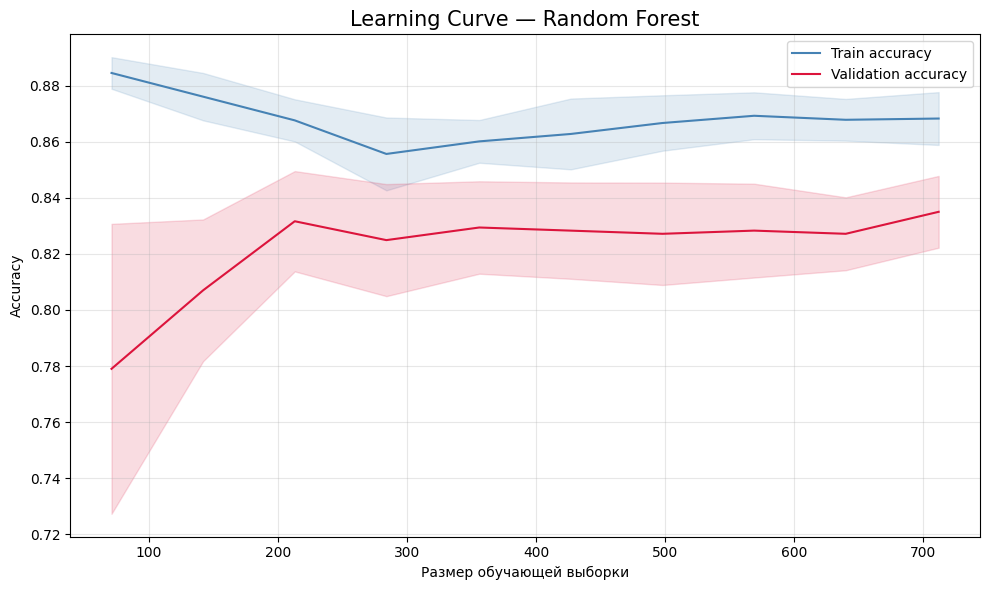

In [23]:
# ============================================
# 13. LEARNING CURVE
# ============================================

train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X_train, y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)

# Считаем среднее и std:
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

# График:
plt.figure(figsize=(10, 6))

# Train линия:
plt.plot(train_sizes, train_mean,
         color='steelblue', label='Train accuracy')
plt.fill_between(train_sizes,
                 train_mean - train_std,
                 train_mean + train_std,
                 alpha=0.15, color='steelblue')

# Validation линия:
plt.plot(train_sizes, val_mean,
         color='crimson', label='Validation accuracy')
plt.fill_between(train_sizes,
                 val_mean - val_std,
                 val_mean + val_std,
                 alpha=0.15, color='crimson')

plt.title('Learning Curve — Random Forest', size=15)
plt.xlabel('Размер обучающей выборки')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
print(submission.head())
print(f"Строк: {len(submission)}")
submission.to_csv('submission.csv', index=False)
print("✅ submission.csv обновлён!")

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
Строк: 418
✅ submission.csv обновлён!
